<a href="https://colab.research.google.com/github/Sanjan193/Custom-AlexNet-For-Lung-Cancer-Classification-Detection/blob/main/Chest_Cancer_CNN(AlexNet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                                         **About Data**


Images are not in dcm format, the images are in jpg or png to fit the model Data contain 3 chest cancer types which are Adenocarcinoma,Large cell carcinoma, Squamous cell carcinoma , and 1 folder for the normal cell Data folder is the main folder that contain all the step folders inside Data folder are test , train , valid

test represent testing set train represent training set valid represent validation set training set is 70% testing set is 20% validation set is 10%

In [ ]:
# !pip install torch_xla #Install this if you use TPU

# **`Imports`**

In [2]:
import kagglehub
import zipfile
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
# import torch_xla #For TPU
# import torch_xla.core.xla_model as xm #For TPU
from sklearn.metrics import accuracy_score


# **`Loading the Lung Cancer data`**

In [6]:
# Downloadimg latest version
path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")

print("Path to dataset files:", path)

# data set directories
train_dir = "/kaggle/input/chest-ctscan-images/Data/train"
valid_dir = "/kaggle/input/chest-ctscan-images/Data/valid"
test_dir  = "/kaggle/input/chest-ctscan-images/Data/test"


Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
Path to dataset files: /kaggle/input/chest-ctscan-images


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


# creating the data set
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=transform)
test_dataset  = datasets.ImageFolder(root=test_dir, transform=transform)
torch.manual_seed(42)
# transforming the images in to the tensors
#each batch has 32 imagesn and their labels
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=12, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

## **`Setting up the device(GPU/TPU)`**

**Using the GPU currently**

In [9]:
# device = 'cuda' if torch.cuda.is_available else 'cpu'
# device = xm.xla_device() #using TPU for faster computation

# print(device)

# **`PLotting the CT-Scan Image of Lung`**

In [10]:
torch.manual_seed(42)
# splitting the creates daat into different image tensor and lablel tensor
train_img_data,train_labels = (next(iter(train_loader)))
test_img_data,test_labels = (next(iter(test_loader)))
valid_img_data,valid_labels = (next(iter(valid_loader)))
print(train_img_data[3].shape)
print("The image has 3 colour channels according to the RGB colour piexels")

torch.Size([3, 224, 224])
The image has 3 colour channels according to the RGB colour piexels


# **Labeling**

**0 = Adenocarcinoma**  
**1 = Large cell carcinoma**       
**2 = Normal**            
**3 = Squamous cell carcinoma**

corresponding label : 0


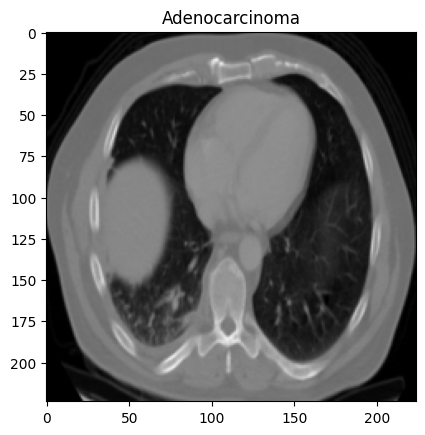

In [17]:
def img(i,data,label):
  plt.imshow(data[20].permute(1,2,0),cmap = 'grey')
  if label[i] == 0 :
    plt.title("Adenocarcinoma")
  elif label[i] == 1 :
    plt.title("Large cell carcinoma")
  elif label[i] == 2 :
    plt.title("Normal")
  if label[i] == 3 :
    plt.title("Squamous cell carcinoma")
  print(f"corresponding label : {label[i]}")

img(9,train_img_data,train_labels)

## **`Seeing the Reshaped Tensors`**

In [ ]:
a = train_img_data[0].permute(1,2,0)
a.shape
#that is used only to generate the image and to print the data

torch.Size([224, 224, 3])

# ***`Creating the CNN (AlexNet) model`***

So basically I'm creating the fundamental architechture of the alexnet model from scratch.

Down here I'm attaching the visually the custom model that i built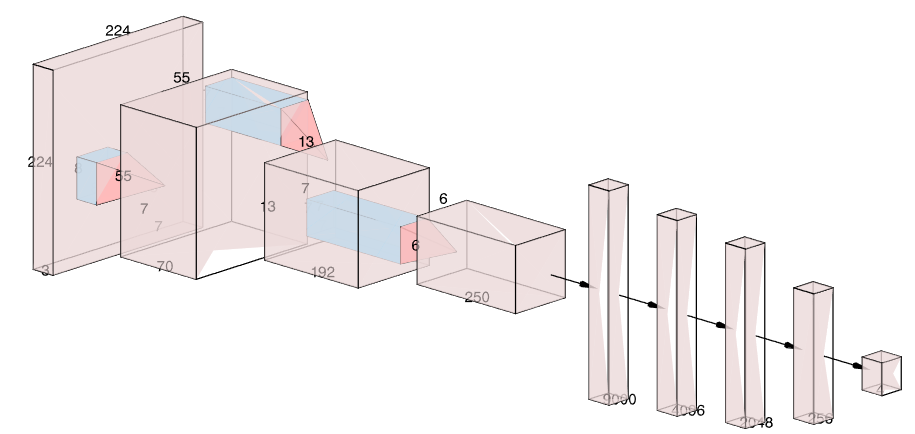

In [ ]:
# Model Architecture
class CNNnet(nn.Module):
  def __init__(self):

    super(CNNnet,self).__init__()

    self.conv = nn.Sequential(

        # CONVO Lyaer 1
        nn.Conv2d(3,70,kernel_size=8,padding=1,stride=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
        # 55*55(height & width) shape after this layer

        # CONVO Lyaer 2
        nn.Conv2d(70,192,kernel_size=7,padding=1,stride=2),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
        # 13*13 (height & width) shape after this layer

        # CONVO Lyaer 3
        nn.Conv2d(192,250,kernel_size=4,padding=1,stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=1),
        # 6*6 (height & width) shape after this layer

    )
    self.average_pooling = nn.AdaptiveAvgPool2d(6)
    self.Neural_Classifier = nn.Sequential(

        nn.Linear(250*6*6,4096),
        nn.BatchNorm1d(4096),
        nn.ReLU(),
        nn.Dropout(0.15),

        nn.Linear(4096,2048),
        nn.BatchNorm1d(2048),
        nn.ReLU(),
        nn.Dropout(0.25),

        nn.Linear(2048,256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.15),

        nn.Linear(256,4),
        # nn.Softmax(dim=1)
    )

  def forward(self,x):
      x = self.conv(x)
      x = self.average_pooling(x)
      x = torch.flatten(x,1)
      x = self.Neural_Classifier(x)
      #x = torch.argmax(x,dim = 1) #(because I'm using cross entropy loss so the taking the max index in the 4 width array here,is not necessary)
      return x



In [ ]:
model_CNN1 = CNNnet()

# moving the model in TPU
model_CNN1 = model_CNN1.to(device)
model_CNN1

CNNnet(
  (conv): Sequential(
    (0): Conv2d(3, 70, kernel_size=(8, 8), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(70, 192, kernel_size=(7, 7), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 250, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (average_pooling): AdaptiveAvgPool2d(output_size=6)
  (Neural_Classifier): Sequential(
    (0): Linear(in_features=9000, out_features=4096, bias=True)
    (1): BatchNorm1d(4096, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=4096, out_features=2048, bias=True)
    (5): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_runn

In [ ]:
list(model_CNN1.parameters())

[Parameter containing:
 tensor([[[[ 5.3319e-02,  9.7739e-03,  3.4799e-02,  ...,  1.0667e-02,
            -3.3691e-02,  1.8396e-02],
           [-3.3251e-02, -8.4634e-03, -2.9312e-02,  ..., -3.3271e-02,
            -2.0379e-02, -4.3393e-02],
           [ 6.8115e-03, -7.1280e-02,  6.5176e-02,  ...,  1.2010e-02,
            -2.3434e-02,  4.4597e-02],
           ...,
           [-5.5355e-02,  5.9217e-02,  2.0787e-02,  ..., -1.2554e-03,
             5.6480e-02, -5.1277e-02],
           [ 4.5440e-03, -4.9258e-02,  2.2253e-02,  ..., -1.5036e-02,
             5.9856e-02, -4.2775e-02],
           [-4.3041e-02, -4.3044e-02,  6.4912e-02,  ..., -5.9559e-02,
            -7.1582e-02, -5.6462e-02]],
 
          [[-4.8547e-02,  2.9231e-02,  2.5842e-02,  ..., -4.9198e-02,
             3.8291e-02, -2.9171e-02],
           [ 4.3801e-02, -1.7126e-02,  4.1284e-02,  ...,  2.2003e-02,
             1.5257e-02, -1.8400e-02],
           [ 4.3018e-02,  4.9061e-02, -5.2335e-02,  ..., -2.4352e-02,
            -2.5

# **`Defining the loss Function`**

In [ ]:
# using Cross Entropy loss best for Multi class classifications (combines LogSoftmax + Loss)
loss = torch.nn.CrossEntropyLoss()

# **`Defining The optimizer`**

In [ ]:
optimizer1 = torch.optim.Adam(model_CNN1.parameters(),lr = .001)
optimizer2 = torch.optim.SGD(model_CNN1.parameters(),lr = .00125,momentum=.28)

# **`Making Training loop`**

In [ ]:
# making the feeding a function
def model_feed(epochs,
               total_loss_per_epoch,
               loss_array_per_epoch,
               loader,
               loss,
               optimizer,
               acc,
               model):

 for epoch in range(epochs) :
      total_loss_per_epoch = 0
      accuracy = 0
      model.train()
      for image,labels in loader:
          #  setting optimizer to zero
           optimizer.zero_grad()

           images = image.to(device)
           labels = labels.to(device)

           output = model(images)

           losses = loss(output,labels)
           total_loss_per_epoch = total_loss_per_epoch + losses

           losses.backward()

           optimizer.step() #for GPU
          #  xm.optimizer_step(optimizer) #for TPU
          #  torch_xla.sync() #gives signal to the tpu for stsrting computation


           # calculating the accuracy in each epochs
           ac_loss = torch.argmax(output,dim = 1 )
           ac = accuracy_score(ac_loss.cpu().numpy(),labels.cpu().numpy())
           accuracy += ac


      acc.append(accuracy/len(loader))
      avg_loss = total_loss_per_epoch/len(loader)
      print("------------------------------------------")
      if epoch % 1 == 0 :
          print(f"Epoch {epoch}, average loss per batch loss = {avg_loss.item()}\n")
          loss_array_per_epoch.append(avg_loss.item())
      print("------------------------------------------")



**Training the model**

In [ ]:
# trianing the model
train_epochs = 150
train_loss_array_per_epoch= [0]
train_loss_per_epoch = 0
accuracy_array_per_epoch = [0]

model_feed(train_epochs,
           train_loss_per_epoch,
           train_loss_array_per_epoch,
           train_loader,
           loss,
           optimizer2,
           accuracy_array_per_epoch,
           model_CNN1)


------------------------------------------
Epoch 0, average loss per batch loss = 1.0487737655639648

------------------------------------------
------------------------------------------
Epoch 1, average loss per batch loss = 0.7927599549293518

------------------------------------------
------------------------------------------
Epoch 2, average loss per batch loss = 0.7296256422996521

------------------------------------------
------------------------------------------
Epoch 3, average loss per batch loss = 0.7042362093925476

------------------------------------------
------------------------------------------
Epoch 4, average loss per batch loss = 0.6303739547729492

------------------------------------------
------------------------------------------
Epoch 5, average loss per batch loss = 0.5368556380271912

------------------------------------------
------------------------------------------
Epoch 6, average loss per batch loss = 0.49756595492362976

---------------------------

In [ ]:
len(train_loss_array_per_epoch)

151

Text(0, 0.5, 'Average batch Losses per Epoch')

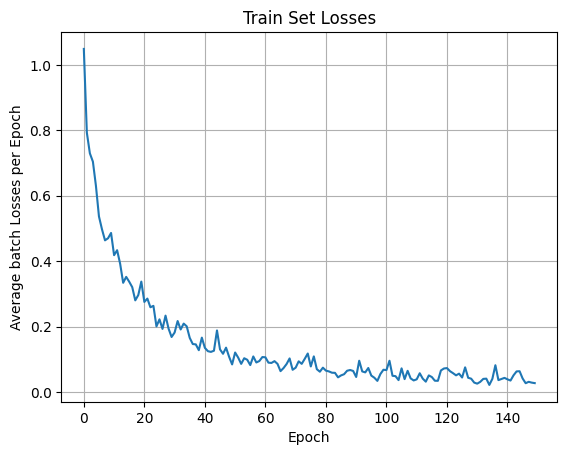

In [ ]:
y_1 = train_loss_array_per_epoch[1:]
x_1 = np.arange(len(y_1))
plt.title("Train Set Losses")
plt.plot(x_1,y_1)
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("Average batch Losses per Epoch")

# **`Now doing the Tesitng Phase`**

**Also colllecting the accuracy of our model, per epochs.**

In [ ]:
optimizer3 = torch.optim.SGD(model_CNN1.parameters(),lr = .00125,momentum=.5)

In [ ]:
test_epochs = 170
test_loss_array_per_epoch= [0]
test_total_loss_per_epoch = 0
accuracy_array = [0]
# giving the testing dat to the model
model_feed(test_epochs,
           test_total_loss_per_epoch,
           test_loss_array_per_epoch,
           valid_loader,
           loss,
           optimizer3,
           accuracy_array,
           model_CNN1)

------------------------------------------
Epoch 0, average loss per batch loss = 0.7945893406867981

------------------------------------------
------------------------------------------
Epoch 1, average loss per batch loss = 0.44420647621154785

------------------------------------------
------------------------------------------
Epoch 2, average loss per batch loss = 0.4048047959804535

------------------------------------------
------------------------------------------
Epoch 3, average loss per batch loss = 0.40612688660621643

------------------------------------------
------------------------------------------
Epoch 4, average loss per batch loss = 0.3582523763179779

------------------------------------------
------------------------------------------
Epoch 5, average loss per batch loss = 0.3127788305282593

------------------------------------------
------------------------------------------
Epoch 6, average loss per batch loss = 0.30110177397727966

-------------------------

In [ ]:
test_loss_array_per_epoch

[0,
 0.7945893406867981,
 0.44420647621154785,
 0.4048047959804535,
 0.40612688660621643,
 0.3582523763179779,
 0.3127788305282593,
 0.30110177397727966,
 0.2538580298423767,
 0.24110595881938934,
 0.23356710374355316,
 0.2821821868419647,
 0.20551030337810516,
 0.16415022313594818,
 0.1602245718240738,
 0.1730494499206543,
 0.12160760164260864,
 0.1296541541814804,
 0.19164131581783295,
 0.1670447438955307,
 0.14610819518566132,
 0.1108408197760582,
 0.14824731647968292,
 0.1508163958787918,
 0.09338359534740448,
 0.0971871018409729,
 0.10413576662540436,
 0.11394547671079636,
 0.07199149578809738,
 0.11912806332111359,
 0.10472872108221054,
 0.10952867567539215,
 0.06357713788747787,
 0.08194475620985031,
 0.11052162945270538,
 0.08151199668645859,
 0.11397340148687363,
 0.07593495398759842,
 0.1378674954175949,
 0.12302596867084503,
 0.12188364565372467,
 0.14051441848278046,
 0.1152934655547142,
 0.05642777681350708,
 0.05233786255121231,
 0.1315089464187622,
 0.07951559126377106,


# **`Plottings`**



In [ ]:
y_2 = test_loss_array_per_epoch[1:]
x_2 = np.arange(test_epochs)

**1.plotting the test loss graph**



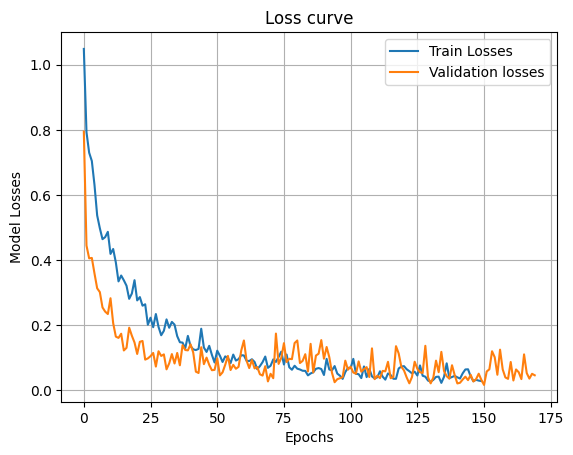

In [ ]:
# Train and test loss graph
plt.plot(x_1,y_1,label = "Train Losses")
plt.plot(x_2,y_2,label = 'Validation losses')
plt.title("Loss curve")
plt.xlabel('Epochs')
plt.ylabel('Model Losses')
plt.grid(True)
plt.legend()
plt.show()

**2.Plotting the accuracy graph for training set and Test set**


In [ ]:
a = np.array(accuracy_array_per_epoch[1:]) #for training
k = np.array(accuracy_array[1:]) #for testing
a.shape

(150,)

Text(0, 0.5, 'Model Train/Test Accuracy %')

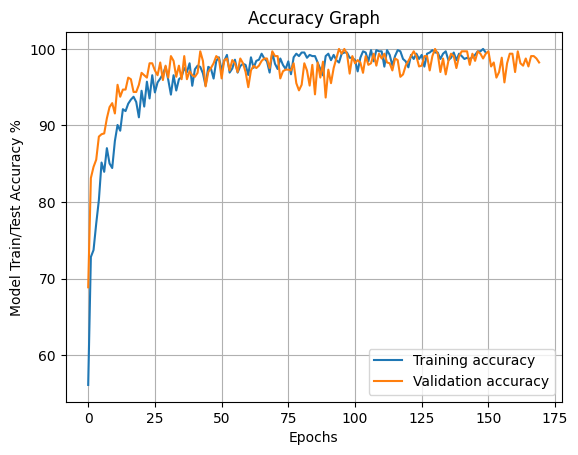

In [ ]:
# train,test accuracy curve
plt.grid(True)
plt.plot(x_1,a*100,label="Training accuracy")
plt.plot(x_2,k*100,label = "Validation accuracy")
plt.title("Accuracy Graph")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Model Train/Test Accuracy %")

# **`Now Calculating the Accuracy of Our Model on Validation Dataset`**

In [ ]:
list(iter(test_loader))

[[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0039, 0.0000, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
            ...,
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
  
           [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0039, 0.0000, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
            ...,
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
  
           [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
            [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
      

In [ ]:
with torch.no_grad():
  count = 0
  avg_accuracy = 0
  for data,label in test_loader:
    # for i in range(0,len(label)):
      count += 1
      data = data.to(device)

      op = model_CNN1(data)
      output = torch.argmax(op,dim=1)
      model_accuracy = accuracy_score(output.cpu().numpy(),label.numpy())
      avg_accuracy += model_accuracy
      print(f"model accuracy for batch {count} :",model_accuracy)
  print("Average accuracy for test set : ",(avg_accuracy/count))


model accuracy for batch 1 : 0.6875
model accuracy for batch 2 : 0.875
model accuracy for batch 3 : 0.875
Average accuracy for test set :  0.8125


**So the final average validation data accuracy we got is : 81.25%**

**And till the 3rd batch is : 87.5%**